<a href="https://colab.research.google.com/github/tanzilahmed0/NFL-Predictions/blob/main/NFL_Predictions_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Dataset Project
By: Tanzil Ahmed & Shivam Shelar

# Introduction
Objective:
This project analyzes historical NFL team performance data to understand and visualize how teams rise and fall over time. Using the FiveThirtyEight NFL Elo dataset spanning multiple decades, we aim to uncover patterns in team performance trajectories and hope to find the factors that contribute to sustained success or decline. For this project we're only going to focus on the Superbowl era of the NFL.


Key Research Questions:
1. How do NFL dynasties form and decline? We'll analyze periods of sustained excellence and what precedes/follows them.
2. How does playoff performance compare to regular season performance? We'll investigate if certain teams consistently shine when the lights are the brightest.
4. What role do quarterbacks play in team performance stability? We'll analyze the relationship between QB ratings and team success.

Significance:
Understanding these patterns is valuable for several reasons:
- Helps teams and analysts identify early indicators of performance trends
- Provides context for evaluating current team trajectories
- Offers insights into the cyclical nature of team success in the NFL
- Can inform strategy decisions about team rebuilding processes

Methodology:
We will use:
1. Statistical analysis of Elo ratings over time
2. Visualization of performance trends
3. Comparative analysis of regular season vs playoff performance
4. Machine learning to predict game outcomes and performance trends


# Dataset  
We used the 538 NFL Elo Dataset which contains game-by-game Elo ratings and forecasts back to 1920.
- `date`:	Date of game
- `season`:	Year of season
- `neutral`:	Whether game was on a neutral site
- `playoff`:	Whether game was in playoffs, and the playoff round if so
- `team1`:	Abbreviation for home team
- `team2`:	Abbreviation for away team
- `elo1_pre`:	Home team's Elo rating before the game
- `elo2_pre`:	Away team's Elo rating before the game
- `elo_prob1`:	Home team's probability of winning according to Elo ratings
- `elo_prob2`:	Away team's probability of winning according to Elo ratings
- `elo1_post`:	Home team's Elo rating after the game
- `elo2_post`:	Away team's Elo rating after the game
- `qbelo1_pre`:	Home team's quarterback-adjusted base rating before the game
- `qbelo2_pre`:	Away team's quarterback-adjusted base rating before the game
- `qb1`:	Name of home starting quarterback
- `qb2`:	Name of away starting quarterback
- `qb1_value_pre`:	Home starting quarterbacks's raw Elo value before the game
- `qb2_value_pre`:	Away starting quarterbacks's raw Elo value before the game
- `qb1_adj`:	Home starting quarterbacks's Elo adjustment for the game
- `qb2_adj`:	Away starting quarterbacks's Elo adjustment for the game
- `qbelo_prob1`:	Home team's probability of winning according to quarterback-adjusted Elo
- `qbelo_prob2`:	Away team's probability of winning according to quarterback-adjusted Elo
- `qb1_game_value`:	Home quarterback's Elo value during this game
- `qb2_game_value`:	Away quarterback's Elo value during this game
- `qb1_value_post`:	Home starting quarterbacks's raw Elo value after the game
- `qb2_value_post`:	Away starting quarterbacks's raw Elo value after the game
- `qbelo1_post`:	Home team's quarterback-adjusted base rating after the game
- `qbelo2_post`:	Away team's quarterback-adjusted base rating after the game
- `score1`:	Home team's score
- `score2`:	Away team's score
- `quality`:	Rating of game's quality, based on the harmonic mean of the teams’ pregame Elo ratings, scaled from 0-100
- `importance`:	Rating of game's importance, based on how much the result would affect the model's forecasted playoff odds, scaled from 0-100
total_rating	The average of quality and importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('https://projects.fivethirtyeight.com/nfl-api/nfl_elo.csv')

df.tail()


,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,elo_prob2,...,qb2_game_value,qb1_value_post,qb2_value_post,qbelo1_post,qbelo2_post,score1,score2,quality,importance,total_rating
17374,2023-01-22,2022,0,d,BUF,CIN,1731.516093,1690.292481,0.648277,0.351723,...,303.726984,225.069808,230.466056,1675.570770,1690.152492,10,27,99.0,100.0,100.0
17375,2023-01-22,2022,0,d,SF,DAL,1708.971847,1640.135262,0.683613,0.316387,...,105.114287,109.133365,191.883277,1719.153115,1619.647034,19,12,98.0,100.0,99.0
17376,2023-01-29,2022,0,c,PHI,SF,1621.987292,1721.375447,0.450672,0.549328,...,56.917741,246.826740,103.911803,1645.507079,1693.213858,31,7,99.0,100.0,100.0
17377,2023-01-29,2022,0,c,KC,CIN,1735.804844,1729.668918,0.600966,0.399034,...,28.185998,280.177715,210.238050,1708.664922,1678.805820,23,20,100.0,100.0,100.0
17378,2023-02-12,2022,1,s,PHI,KC,1657.913193,1746.521889,0.375176,0.624824,...,411.098145,268.147365,293.269758,1633.804536,1720.367465,35,38,100.0,100.0,100.0


# Data Preparation

In this stage of the project, we aim to clean the data to derive effective insights

In [ ]:
# Display initial info about the dataset
print("Initial data info:")
print(df.info())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Data type conversions
df['date'] = pd.to_datetime(df['date'])
df['season'] = df['season'].astype('int64')
df['neutral'] = df['neutral'].astype('bool')

Initial data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            17379 non-null  object 
 1   season          17379 non-null  int64  
 2   neutral         17379 non-null  int64  
 3   playoff         616 non-null    object 
 4   team1           17379 non-null  object 
 5   team2           17379 non-null  object 
 6   elo1_pre        17379 non-null  float64
 7   elo2_pre        17379 non-null  float64
 8   elo_prob1       17379 non-null  float64
 9   elo_prob2       17379 non-null  float64
 10  elo1_post       17379 non-null  float64
 11  elo2_post       17379 non-null  float64
 12  qbelo1_pre      15217 non-null  float64
 13  qbelo2_pre      15217 non-null  float64
 14  qb1             15217 non-null  object 
 15  qb2             15217 non-null  object 
 16  qb1_value_pre   15217 non-null  float64
 17  qb2_value_pr

Only want to cover Superbowl Era Seasons from 1966 onwards

In [ ]:
# Create game type category
df['game_type'] = df['playoff'].fillna('regular').map({
    'regular': 'Regular Season',
    'w': 'Wild Card',
    'd': 'Divisional',
    'c': 'Conference Championship',
    's': 'Super Bowl'
})

# Calculate derived metrics
df['point_differential'] = df['score1'] - df['score2']
df['team1_won'] = df['score1'] > df['score2']
df['elo1_change'] = df['elo1_post'] - df['elo1_pre']
df['elo2_change'] = df['elo2_post'] - df['elo2_pre']

In [ ]:
# Check for impossibly high/low Elo ratings
elo_cols = ['elo1_pre', 'elo2_pre', 'elo1_post', 'elo2_post']
for col in elo_cols:
    suspect_elos = df[~df[col].between(1000, 2000)]
    if len(suspect_elos) > 0:
        print(f"\nFound {len(suspect_elos)} suspect {col} values")
        print(suspect_elos[['date', 'team1', 'team2', col]])

In [ ]:
# Calculate basic summary statistics
print("\nBasic Elo statistics:")
print(df[elo_cols].describe())

# Print summary of game types
print("\nGame type distribution:")
print(df['game_type'].value_counts())


Basic Elo statistics:
           elo1_pre      elo2_pre     elo1_post     elo2_post
count  17379.000000  17379.000000  17379.000000  17379.000000
mean    1503.126581   1499.466791   1502.835259   1499.758115
std      104.831615    104.152876    107.363540    106.340927
min     1119.595000   1156.551000   1119.595000   1153.902000
25%     1430.257000   1426.660962   1427.690984   1425.084500
50%     1504.837000   1500.855000   1504.585000   1500.921000
75%     1578.274381   1576.083050   1580.895000   1577.100500
max     1839.663000   1849.484000   1849.484000   1831.462000

Game type distribution:
game_type
Regular Season             16763
Divisional                   234
Wild Card                    168
Conference Championship      157
Super Bowl                    57
Name: count, dtype: int64


Top 5 Teams by Mean Elo Rating:
        Mean_Elo      Max_Elo   Min_Elo     Elo_Std  Total_Games  \
DAL  1567.710558  1767.713000  1286.147   92.744034        476.0   
PIT  1557.226905  1764.342000  1258.864   92.268399        480.0   
NE   1552.009575  1839.663000  1245.565  125.270327        475.0   
BAL  1548.971790  1752.748592  1352.038   77.940736        226.0   
MIN  1542.815978  1756.142000  1337.034   81.851578        465.0   

     Seasons_Played  
DAL            57.0  
PIT            57.0  
NE             57.0  
BAL            27.0  
MIN            57.0  


Text(0, 0.5, 'Count')

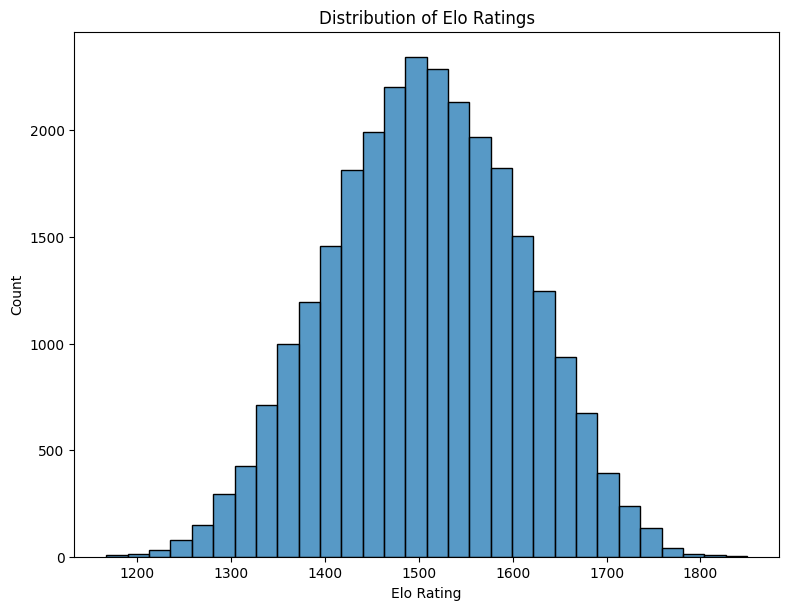

In [ ]:
# Filter for Superbowl Era
df = df[df['season'] >= 1966].copy()

# Calculate team-wise statistics
team_stats = pd.DataFrame()
for team in df['team1'].unique():
    team_data = df[df['team1'] == team]
    team_stats.loc[team, 'Mean_Elo'] = team_data['elo1_pre'].mean()
    team_stats.loc[team, 'Max_Elo'] = team_data['elo1_pre'].max()
    team_stats.loc[team, 'Min_Elo'] = team_data['elo1_pre'].min()
    team_stats.loc[team, 'Elo_Std'] = team_data['elo1_pre'].std()
    team_stats.loc[team, 'Total_Games'] = len(team_data)
    team_stats.loc[team, 'Seasons_Played'] = team_data['season'].nunique()


# Sort teams by mean Elo and get top 5
team_stats = team_stats.sort_values('Mean_Elo', ascending=False)
top_teams = team_stats.head(5).index.tolist()

print("Top 5 Teams by Mean Elo Rating:")
print(team_stats.head())

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 15))

# 1. Distribution of Elo Ratings
ax1 = plt.subplot(2, 2, 1)
combined_elo = pd.concat([df['elo1_pre'], df['elo2_pre']])
sns.histplot(data=combined_elo, bins=30, ax=ax1)
ax1.set_title('Distribution of Elo Ratings')
ax1.set_xlabel('Elo Rating')
ax1.set_ylabel('Count')

We can see that the distribution of elo rating is normally distributed.

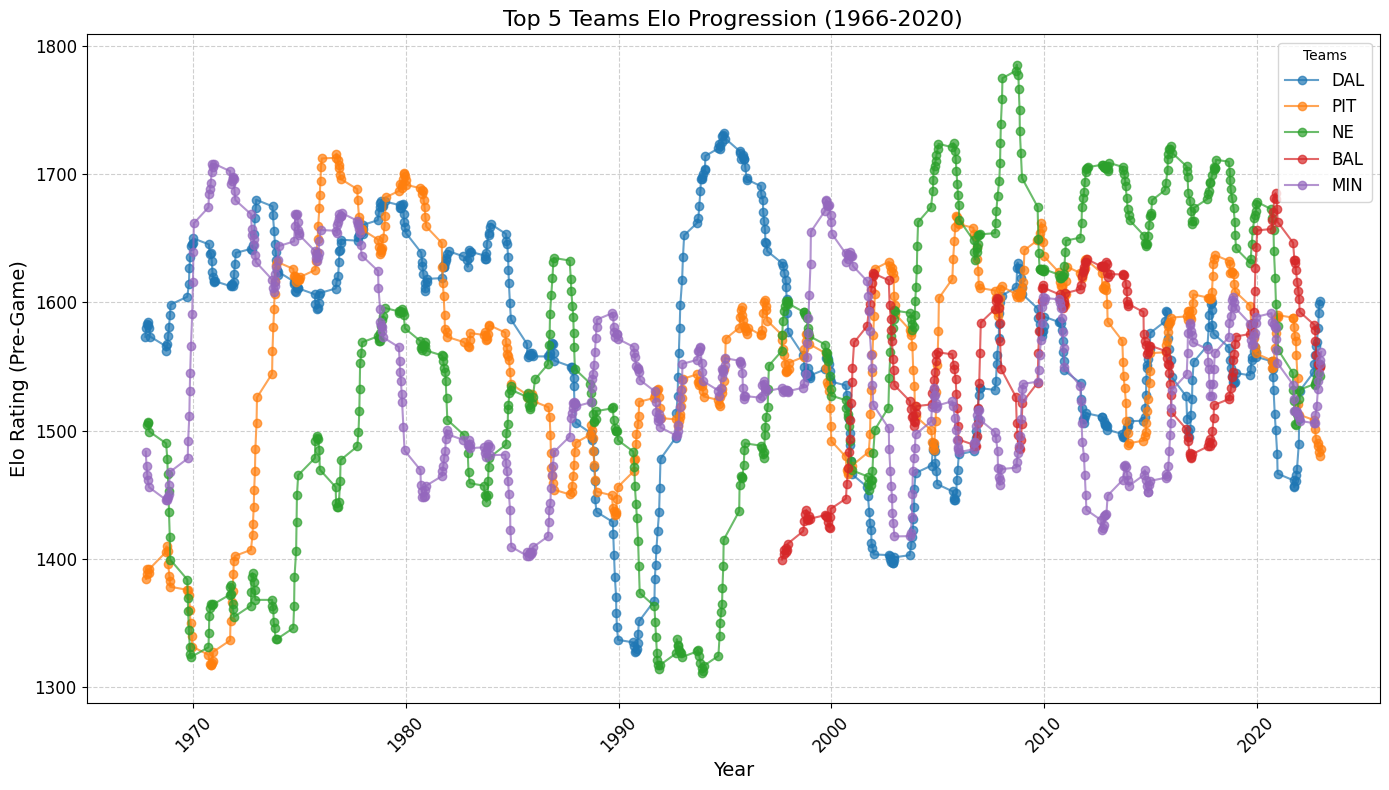

In [ ]:
# 2. Top Teams Elo Progression
plt.figure(figsize=(14, 8))

# Loop through top teams and plot Elo progression
for team in top_teams:
    # Filter data for the current team
    team_games = df[df['team1'] == team]

    # Plot the rolling average to smooth out Elo trends
    team_games = team_games.sort_values('date')  # Ensure dates are sorted
    team_games['elo_rolling_avg'] = team_games['elo1_pre'].rolling(window=10).mean()

    plt.plot(
        team_games['date'],
        team_games['elo_rolling_avg'],
        label=team,
        marker='o',
        alpha=0.7  # Add transparency for clarity
    )

# Add title and axis labels with more context

plt.title('Top 5 Teams Elo Progression (1966-2020)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Elo Rating (Pre-Game)', fontsize=14)

# Add gridlines to enhance readability
plt.grid(True, linestyle='--', alpha=0.6)

# Add legend
plt.legend(title='Teams', fontsize=12)

# Rotate x-axis labels for better alignment
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
!pip install jupyter_bokeh

In [ ]:
import plotly.express as px
import panel as pn

pn.extension('plotly')

# Get list of all teams
teams = sorted(df['team1'].unique())

def create_team_plot(team_selection):
    # This function creates the elo plot for selected team
    team_data = df[df['team1'] == team_selection].copy()

    # Create figure with plotly express
    fig = px.line(
        team_data,
        x='date',
        y='elo1_pre',
        title=f'{team_selection} Elo Rating Progression',
        labels={'date': 'Date', 'elo1_pre': 'Elo Rating'},
        color_discrete_sequence=['green'],
    )

    # Add playoff games as scatter points
    playoff_fig = px.scatter(
        team_data[team_data['playoff'].notna()],
        x='date',
        y='elo1_pre',
        color_discrete_sequence=['red'],
        hover_data={'date': True, 'elo1_pre': ':.1f', 'playoff': True}
    )

    # Combine the figures
    fig.add_traces(playoff_fig.data)

    # Update layout to include a range slider at the bottom
    fig.update_layout(
        height=500,
        title_font_size=18,
        title_x=0.5,
        plot_bgcolor='white',
        font=dict(size=12),
        xaxis=dict(
            title='Date',
            title_font=dict(size=14),
            # Enable range slider
            rangeslider=dict(visible=True, thickness=0.1),
            showgrid=True,
        ),
        yaxis=dict(
            title='Elo Rating',
            title_font=dict(size=14),
            showgrid=True
        )
    )
    return fig

def create_stats_panel(team):
    """Create Stats Panel for a Team."""
    team_data = df[df['team1'] == team]

    stats = [
        f"**Average Elo:** {team_data['elo1_pre'].mean():.1f}",
        f"**Highest Elo:** {team_data['elo1_pre'].max():.1f}",
        f"**Lowest Elo:** {team_data['elo1_pre'].min():.1f}",
        f"**Standard Deviation:** {team_data['elo1_pre'].std():.1f}",
        "",
        "**Games:**",
        f"- Total Games: {len(team_data)}",
        f"- Playoff Games: {len(team_data[team_data['playoff'].notna()])}",
        f"- Regular Season Games: {len(team_data[team_data['playoff'].isna()])}",
        "",
        "**Season Range:**",
        f"- First Game: {team_data['date'].min().strftime('%Y-%m-%d')}",
        f"- Last Game: {team_data['date'].max().strftime('%Y-%m-%d')}"
    ]

    return pn.pane.Markdown(
        "\n".join(stats),
        sizing_mode='stretch_width'
    )

# Team selector widget
team_selector = pn.widgets.Select(
    name='Select Team',
    options=teams,
    value=teams[0],
    width=200
)

# Layout update function
@pn.depends(team_selector.param.value)
def update_dashboard(team):
    return pn.Row(
        pn.Column(
            team_selector,
            create_stats_panel(team),
            # Adjust column width
            width=300,
            sizing_mode='fixed'
        ),
        pn.pane.Plotly(
            create_team_plot(team),
            sizing_mode='stretch_both',
            height=500
        )
    )

# Dashboard layout
dashboard = pn.Column(
    pn.pane.Markdown(
        "## **NFL Team Elo Rating Progression**",
        sizing_mode='stretch_width'
    ),
    update_dashboard
)


dashboard


Column
    [0] Markdown(str, sizing_mode='stretch_width')
    [1] ParamFunction(function, _pane=Row, defer_load=False)

In [ ]:
# Calculate how much elo was gained/lost after each game for home and away teams

df['elo1_gain'] = df['elo1_post'] - df['elo1_pre']
df['elo2_gain'] = df['elo2_post'] - df['elo2_pre']
df['abs_elo_gain']  = abs(df['elo1_post'] - df['elo1_pre'])


# Create team win and score diff column
df['team1_win'] = (df['score1'] > df['score2']).astype(int)
df['team2_win'] = (df['score2'] > df['score1']).astype(int)

df['score_diff'] = df['score1'] - df['score2']

df.tail()

,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,elo_prob2,...,point_differential,team1_won,elo1_change,elo2_change,elo1_gain,elo2_gain,abs_elo_gain,team1_win,team2_win,score_diff
17374,2023-01-22,2022,False,d,BUF,CIN,1731.516093,1690.292481,0.648277,0.351723,...,-17,False,-39.376436,39.376436,-39.376436,39.376436,39.376436,0,1,-17
17375,2023-01-22,2022,False,d,SF,DAL,1708.971847,1640.135262,0.683613,0.316387,...,7,True,12.403599,-12.403599,12.403599,-12.403599,12.403599,1,0,7
17376,2023-01-29,2022,False,c,PHI,SF,1621.987292,1721.375447,0.450672,0.549328,...,24,True,35.925901,-35.925901,35.925901,-35.925901,35.925901,1,0,24
17377,2023-01-29,2022,False,c,KC,CIN,1735.804844,1729.668918,0.600966,0.399034,...,3,True,10.717044,-10.717044,10.717044,-10.717044,10.717044,1,0,3
17378,2023-02-12,2022,True,s,PHI,KC,1657.913193,1746.521889,0.375176,0.624824,...,-3,False,-9.999360,9.999360,-9.999360,9.999360,9.999360,0,1,-3


This function calculates a rolling average of Elo ratings over a window size for the given team, and identifies the 90th percentile rolling elo values which is what we deemed as peak periods of the team.

In [ ]:
def analyze_peak_periods(df, team, window=16):
    team_data = df[df['team1'] == team].copy()
    team_data['rolling_elo'] = team_data['elo1_pre'].rolling(window=window).mean()

    # Find peaks (periods of sustained high performance)
    peak_threshold = team_data['rolling_elo'].quantile(0.9)
    peak_periods = team_data[team_data['rolling_elo'] > peak_threshold]

    return peak_periods

# Example usage for a specific team
team = "NE"  # New England Patriots
peak_periods = analyze_peak_periods(df, team)
peak_periods

,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,elo_prob2,...,team1_won,elo1_change,elo2_change,elo1_gain,elo2_gain,abs_elo_gain,team1_win,team2_win,score_diff,rolling_elo
12512,2005-01-02,2004,False,NaN,NE,SF,1763.581000,1300.856000,0.954254,0.045746,...,True,1.998000,-1.999000,1.998000,-1.999000,1.998000,1,0,14,1702.155250
12531,2005-01-16,2004,False,d,NE,IND,1765.579000,1693.073000,0.688164,0.311836,...,True,16.966000,-16.966000,16.966000,-16.966000,16.966000,1,0,17,1711.601938
12536,2005-09-08,2005,False,NaN,NE,OAK,1712.670000,1403.871000,0.895833,0.104167,...,True,4.270000,-4.271000,4.270000,-4.271000,4.270000,1,0,10,1716.250687
12582,2005-10-02,2005,False,NaN,NE,LAC,1697.402000,1547.560000,0.774994,0.225006,...,False,-55.291000,55.292000,-55.291000,55.292000,55.291000,0,1,-24,1717.758812
12639,2005-10-30,2005,False,NaN,NE,BUF,1633.830000,1488.388000,0.770547,0.229453,...,True,7.505000,-7.505000,7.505000,-7.505000,7.505000,1,0,5,1714.337750
12665,2005-11-07,2005,False,NaN,NE,IND,1641.335000,1706.777000,0.499364,0.500636,...,False,-29.913000,29.913000,-29.913000,29.913000,29.913000,0,1,-19,1710.235625
12685,2005-11-20,2005,False,NaN,NE,NO,1626.133000,1387.499000,0.851682,0.148318,...,True,5.420000,-5.421000,5.420000,-5.421000,5.420000,1,0,7,1704.601062
12718,2005-12-04,2005,False,NaN,NE,NYJ,1606.444000,1415.938000,0.813181,0.186819,...,True,8.835000,-8.834000,8.835000,-8.834000,8.835000,1,0,13,1697.157625
13298,2007-12-23,2007,False,NaN,NE,MIA,1824.224000,1315.198000,0.964578,0.035422,...,True,1.737000,-1.737000,1.737000,-1.737000,1.737000,1,0,21,1709.599000
13330,2008-01-12,2007,False,d,NE,JAX,1831.462000,1638.157000,0.815616,0.184384,...,True,8.201000,-8.201000,8.201000,-8.201000,8.201000,1,0,11,1722.504312


Let's see who are the most valuable quarterbacks for team performance

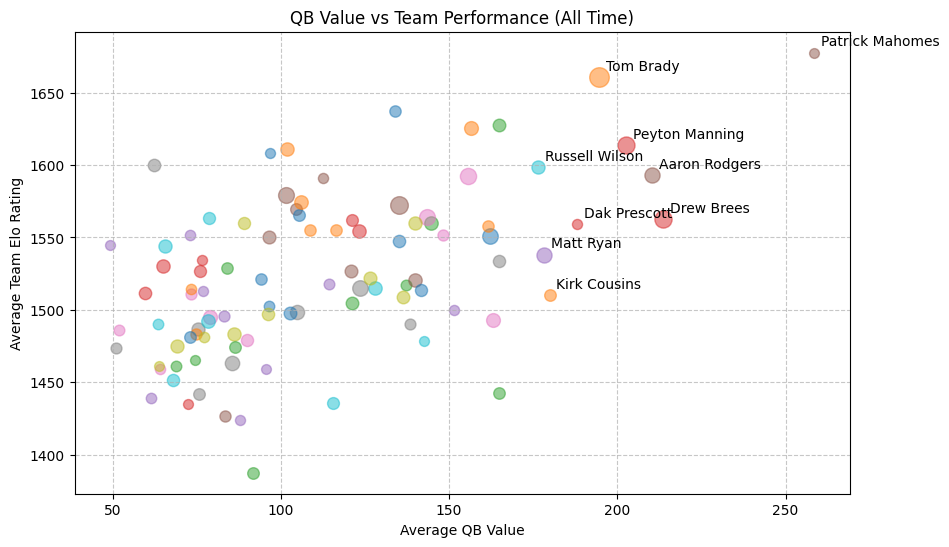

In [ ]:
# Group data by QB and calculate means
qb_stats = []
for qb in df['qb1'].unique():
    # Get all games for this QB
    qb_games = df[df['qb1'] == qb]

    # Only include QBs with at least 50 games
    if len(qb_games) >= 50:
        qb_stats.append({
            'qb': qb,
            'games': len(qb_games),
            'avg_qb_value': qb_games['qb1_value_pre'].mean(),
            'avg_team_elo': qb_games['elo1_pre'].mean()
        })

# Create a new figure
plt.figure(figsize=(10, 6))

# Create scatter plot
for qb in qb_stats:
    plt.scatter(qb['avg_qb_value'], qb['avg_team_elo'], s=qb['games'], alpha=0.5)

    # Label top QBs
    if qb['avg_qb_value'] > 175:
        plt.annotate(qb['qb'],
                    (qb['avg_qb_value'], qb['avg_team_elo']),
                    xytext=(5, 5), textcoords='offset points')

# Add labels and title
plt.xlabel('Average QB Value')
plt.ylabel('Average Team Elo Rating')
plt.title('QB Value vs Team Performance (All Time)')

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

There's a clear positive relationship between QB value and team Elo rating.
Better quarterbacks tend to play for better teams or they just make their team better. There's also a tier of the absolute elite QBs in the top right. Patrick Mahomes stands out as an outlier with the highest QB value with the highest team elo. Most QBs are clustered in the middle range (Between 125-175). This plot shows that QB play is pretty important. The best teams usually have really good QBS, so it is an important feature for predicting wins.



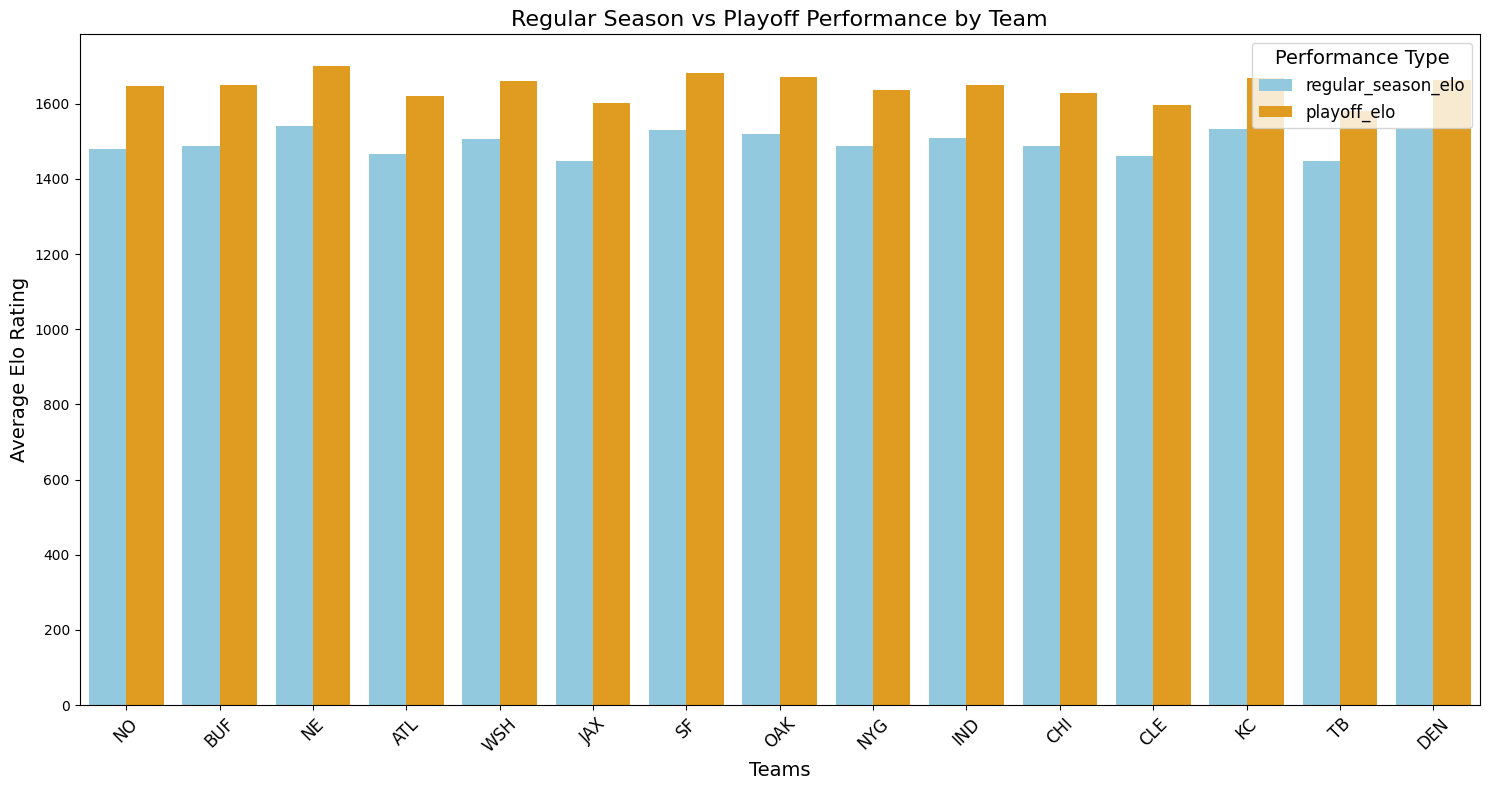

In [ ]:
def plot_playoff_performance(df):
    # Calculate playoff vs regular season performance for each team
    team_stats = []

    for team in df['team1'].unique():
        team_games = df[df['team1'] == team]

        regular_elo = team_games[team_games['playoff'].isna()]['elo1_pre'].mean()
        playoff_elo = team_games[team_games['playoff'].notna()]['elo1_pre'].mean()

        if not pd.isna(playoff_elo):
            team_stats.append({
                'team': team,
                'regular_season_elo': regular_elo,
                'playoff_elo': playoff_elo,
                'differential': playoff_elo - regular_elo
            })

    stats_df = pd.DataFrame(team_stats)
    stats_df = stats_df.sort_values('differential', ascending=False).head(15)

    # Melt the DataFrame for easier plotting with Seaborn
    stats_melted = stats_df.melt(
        id_vars=['team'],
        value_vars=['regular_season_elo', 'playoff_elo'],
        var_name='Performance Type',
        value_name='Average Elo'
    )

    # Create the plot
    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=stats_melted,
        x='team',
        y='Average Elo',
        hue='Performance Type',
        palette={'regular_season_elo': 'skyblue', 'playoff_elo': 'orange'}
    )

    # Customize the plot
    plt.xlabel('Teams', fontsize=14)
    plt.ylabel('Average Elo Rating', fontsize=14)
    plt.title('Regular Season vs Playoff Performance by Team', fontsize=16)
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(title='Performance Type', fontsize=12, title_fontsize=14)
    plt.tight_layout()
    plt.show()

plot_playoff_performance(df)

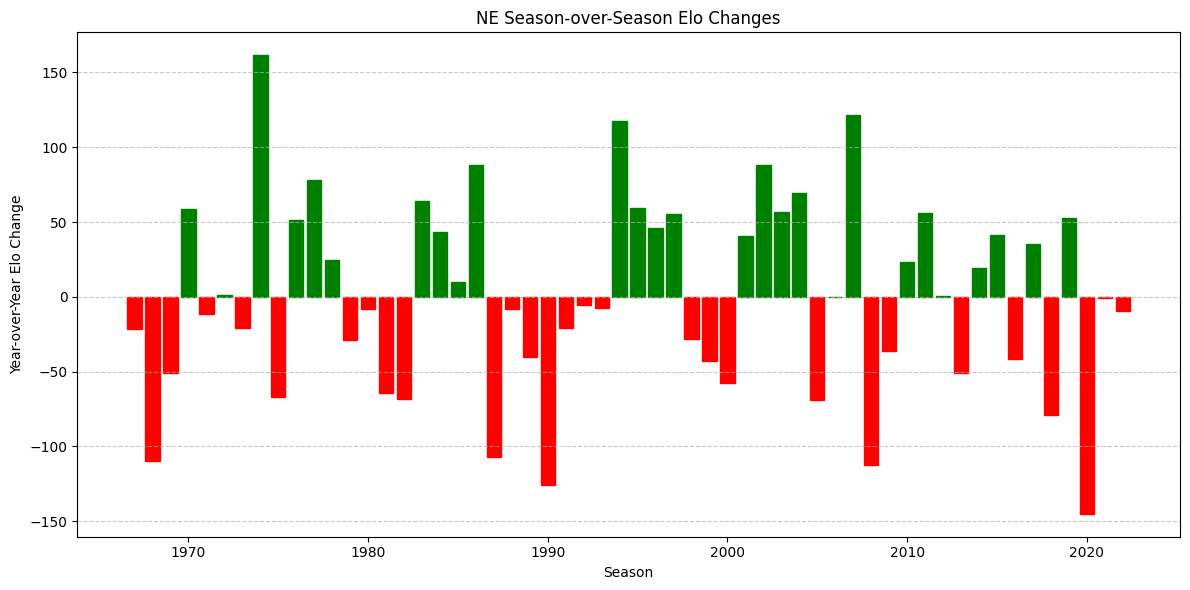

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def analyze_team_season_changes(df, team):

    # Analyze a team's season-over-season performance changes.
    # Create a bar plot to show year-over-year Elo changes.

    # Filter data for the selected team and calculate season averages
    team_data = df[df['team1'] == team].copy()
    team_data['season_avg_elo'] = team_data.groupby('season')['elo1_pre'].transform('mean')

    # Calculate year-over-year changes
    yearly_changes = team_data.groupby('season')['season_avg_elo'].mean().diff().reset_index()
    yearly_changes.columns = ['season', 'yoy_change']

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(yearly_changes['season'], yearly_changes['yoy_change'], color='blue')

    # Highlight positive and negative changes
    for bar in bars:
        if bar.get_height() < 0:
            bar.set_color('red')
        else:
            bar.set_color('green')

    # Add plot labels and title
    plt.title(f"{team} Season-over-Season Elo Changes")
    plt.xlabel("Season")
    plt.ylabel("Year-over-Year Elo Change")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
analyze_team_season_changes(df, 'NE')


This plot shows the season over season Elo changes and it shows team stablility. Green bars are positive changes and red bars are negative changes, and they show how consistent a team is. For the Patriots, 2000-2019 which is the Brady-Belichick era is mostly positive with green bars. However, you can see after Brady's departure, the steep decline.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Create basic features
features_df = pd.DataFrame()
features_df['elo_diff'] = df['elo1_pre'] - df['elo2_pre']
features_df['qb_value_diff'] = df['qb1_value_pre'] - df['qb2_value_pre']
features_df['is_home'] = ~df['neutral'].astype(bool)
features_df['is_playoff'] = df['playoff'].notna()

# 3. QB performance metrics
features_df['qb1_adj'] = df['qb1_adj']
features_df['qb2_adj'] = df['qb2_adj']
features_df['qb_adj_diff'] = df['qb1_adj'] - df['qb2_adj']

# 4. Win probability features
features_df['qbelo_prob_diff'] = df['qbelo_prob1'] - df['qbelo_prob2']

# Create target variable
features_df['target'] = (df['score1'] > df['score2']).astype(int)



In [ ]:
# Split features and target
X = features_df.drop('target', axis=1)
y = features_df['target']

# Create train/test split using 2022 season as test set
train_mask = (df['season'] < 2022)
X_train = X[train_mask]
X_test = X[~train_mask]
y_train = y[train_mask]
y_test = y[~train_mask]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)





In [ ]:
# Train Logistic Regression on PCA-transformed features
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_pca, y_train)



# Predict and evaluate
y_pred = log_model.predict(X_test_pca)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.6514084507042254
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.49      0.55       124
           1       0.66      0.78      0.71       160

    accuracy                           0.65       284
   macro avg       0.65      0.63      0.63       284
weighted avg       0.65      0.65      0.64       284



In [ ]:
# Train Random Forest on PCA-transformed features
forest_model = RandomForestClassifier(random_state=42, n_estimators=200)
forest_model.fit(X_train_pca, y_train)

# Predict and evaluate Random Forest
y_pred_forest = forest_model.predict(X_test_pca)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_forest))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_forest))

Random Forest Accuracy: 0.602112676056338
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.49      0.52       124
           1       0.64      0.69      0.66       160

    accuracy                           0.60       284
   macro avg       0.59      0.59      0.59       284
weighted avg       0.60      0.60      0.60       284



In [ ]:
log_model = LogisticRegression(random_state=42, class_weight='balanced')

log_model.fit(X_train_pca, y_train)



# Predict and evaluate
y_pred = log_model.predict(X_test_pca)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.6584507042253521
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63       124
           1       0.72      0.65      0.68       160

    accuracy                           0.66       284
   macro avg       0.66      0.66      0.66       284
weighted avg       0.66      0.66      0.66       284



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_pca, y_train)
print("Best C value:", grid_search.best_params_)


Best C value: {'C': 0.01}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    n_iter=5,  # Number of parameter settings to sample
    cv=5,
    scoring='accuracy',
    random_state=42
)
random_search_rf.fit(X_train_pca, y_train)
print("Best Parameters for Random Forest:", random_search_rf.best_params_)


Best Parameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}


# Results
The accuracy for the logistic regression model is 65% which is not terrible, but not particularly good either.  $

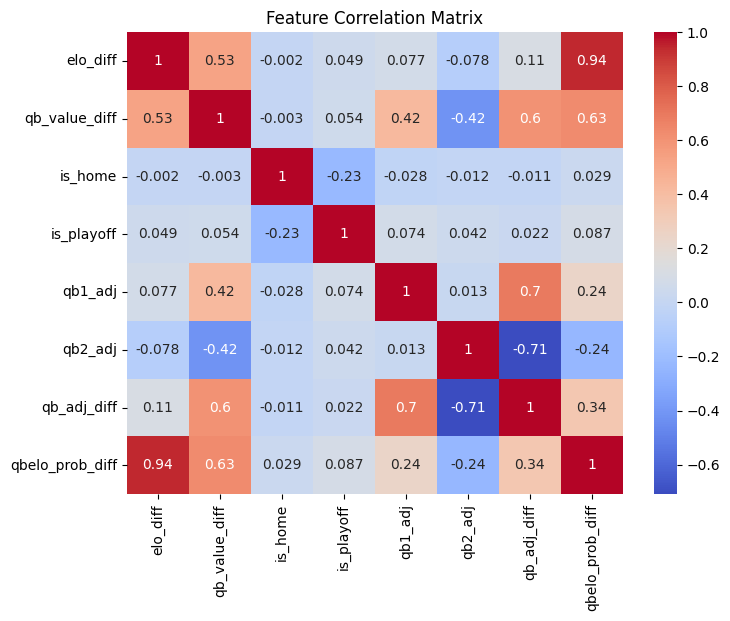

In [ ]:
# Plot feature correlations
plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [ ]:
# Retrain Random Forest with the best parameters from RandomizedSearchCV
best_rf_model = random_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_pca)

# Evaluate the model
print("\nRandom Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Evaluation:
Accuracy: 0.6302816901408451
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.59      0.58       124
           1       0.68      0.66      0.67       160

    accuracy                           0.63       284
   macro avg       0.62      0.63      0.63       284
weighted avg       0.63      0.63      0.63       284



In [ ]:
# Retrain Logistic Regression with the best parameters
best_log_model = grid_search.best_estimator_  # Use the best estimator from GridSearchCV
y_pred_logreg = best_log_model.predict(X_test_pca)  # Ensure X_test_pca is preprocessed similarly to X_train_pca

# Evaluate the Logistic Regression model
print("\nLogistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


Logistic Regression Evaluation:
Accuracy: 0.6584507042253521
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.67      0.63       124
           1       0.72      0.65      0.68       160

    accuracy                           0.66       284
   macro avg       0.66      0.66      0.66       284
weighted avg       0.66      0.66      0.66       284



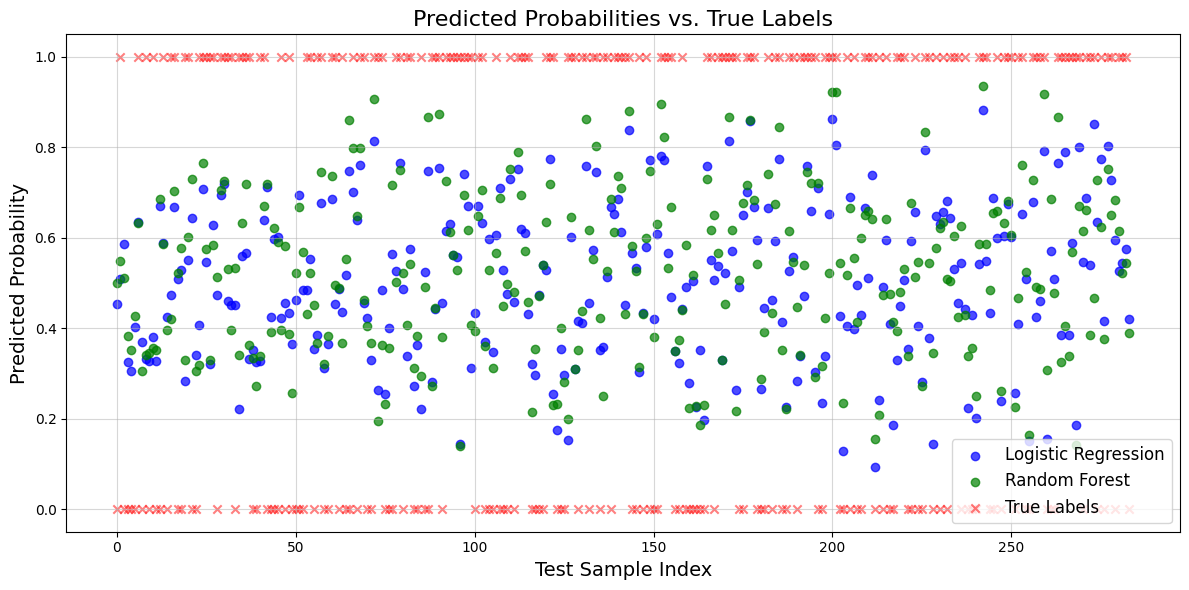

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate predicted probabilities for both models
log_probabilities = best_log_model.predict_proba(X_test_pca)[:, 1]  # Probability of class 1
rf_probabilities = best_rf_model.predict_proba(X_test_pca)[:, 1]  # Probability of class 1

# Scatter plot of predictions
plt.figure(figsize=(12, 6))

# Logistic Regression scatter plot
plt.scatter(range(len(y_test)), log_probabilities, alpha=0.7, label='Logistic Regression', color='blue')

# Random Forest scatter plot
plt.scatter(range(len(y_test)), rf_probabilities, alpha=0.7, label='Random Forest', color='green')

# True labels as a reference
plt.scatter(range(len(y_test)), y_test, alpha=0.5, label='True Labels', color='red', marker='x')

# Plot formatting
plt.title('Predicted Probabilities vs. True Labels', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=14)
plt.ylabel('Predicted Probability', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()

# Display the plot
plt.show()


Let's build a confusion matrix to see just how well the model predicts

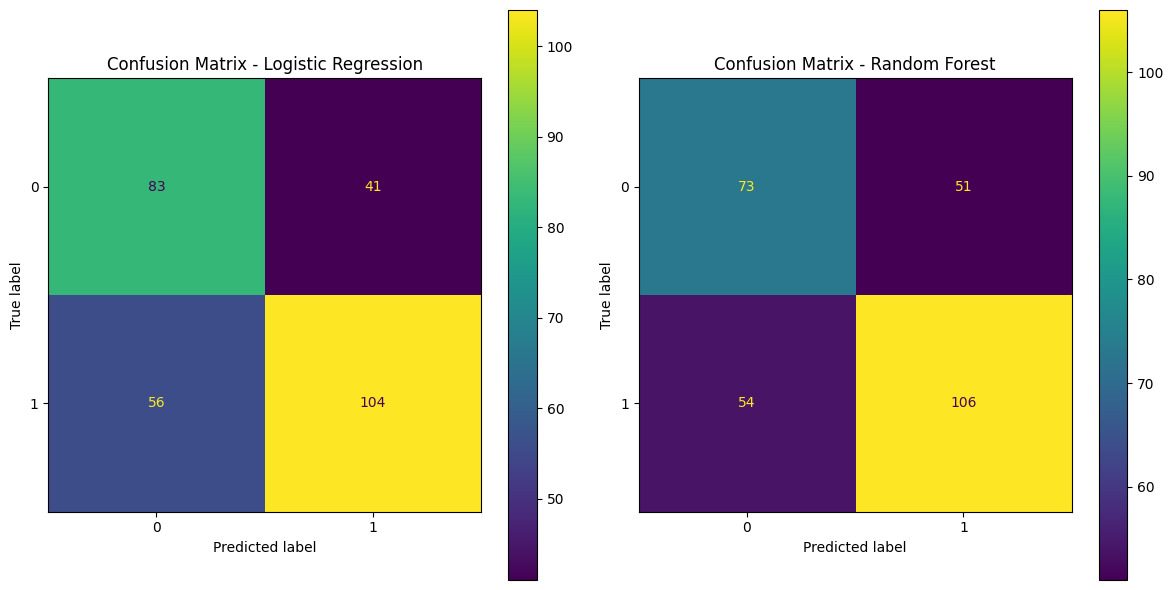

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_log_model, X_test_pca, y_test, ax=axes[0])
axes[0].set_title("Confusion Matrix - Logistic Regression")

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test_pca, y_test, ax=axes[1])
axes[1].set_title("Confusion Matrix - Random Forest")

# Adjust layout and display
plt.tight_layout()
plt.show()